In [92]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd
import cme.utils.common_utils as cu

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import scipy as sci
import seaborn.objects as so
import matplotlib.pyplot as plt
import cme.simulators.diffusion_random_walk as drw

#sns.set_context("paper", font_scale=2.5)
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'plotly_mimetype+notebook'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [2]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 11, 5, 0.1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")
mv_arr = cu.get_conf_limits(n_states)

In [3]:
add_scale, mul_scale = 0,1

In [4]:
m_mu, m_sigma, T = npx.asarray([[2]]), npx.asarray([[3]]), 100
q_mu, q_sigma, T = npx.asarray([[2]]), npx.asarray([[3]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [5]:
intensity_matrix_markov.squeeze()

Array([[-3. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 3. , -3. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  2.5, -3. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  2.5, -3. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  2.5, -3. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  2.5, -3. ,  0.5,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  2.5, -3. ,  0.5,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  2.5, -3. ,  0.5,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  2.5, -3. ,  0.5,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  2.5, -3. ,  3. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  2.5, -3. ]],      dtype=float64)

In [6]:
theta, alpha, tau = 0.9, 1.5, 0.01

mu, sigma_coef = np.asarray([2]), np.asarray([1])

n_states = drw._get_n_states(alpha, theta, tau, sigma_coef)
discrete_transition_matrix = drw.get_transition_matrix(alpha, tau, sigma_coef[0], mu, process="Wiener", n_states=n_states).round(decimals=2)
discrete_transition_matrix.shape

(11, 11)

In [7]:
sns.color_palette("Blues")[1:]

[(0.7309496347558632, 0.8394771241830065, 0.9213225682429834),
 (0.5356862745098039, 0.746082276047674, 0.8642522106881968),
 (0.32628988850442137, 0.6186236063052672, 0.802798923490965),
 (0.16696655132641292, 0.48069204152249134, 0.7291503267973857),
 (0.044059976931949255, 0.3338869665513264, 0.6244521337946944)]

Text(0.5, 1.0, 'Discrete Time')

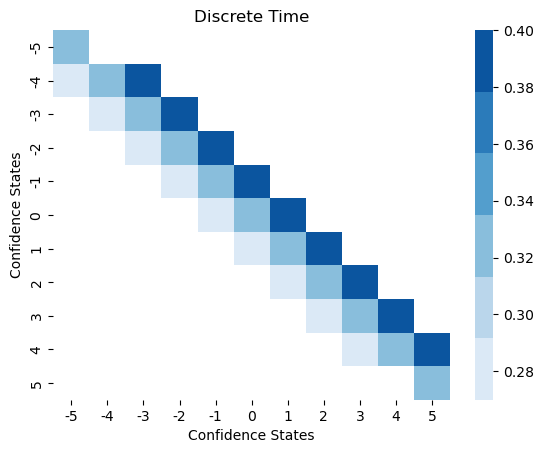

In [8]:
ax = sns.heatmap(np.where(discrete_transition_matrix.squeeze()==0,np.nan,discrete_transition_matrix.squeeze()) ,
    cmap = sns.color_palette("Blues"), xticklabels=mv_arr, yticklabels=mv_arr)
ax.set_xlabel("Confidence States")
ax.set_ylabel("Confidence States")
ax.set_title("Discrete Time")

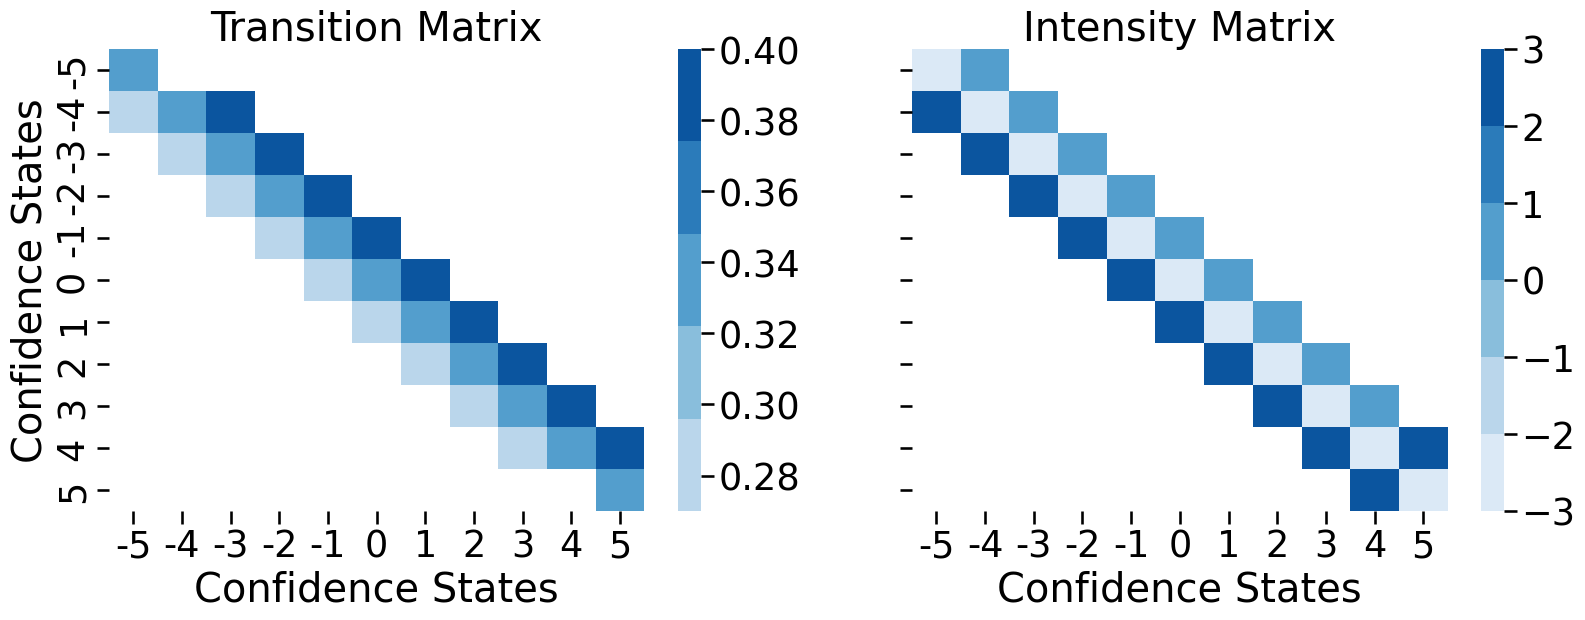

In [9]:
with sns.plotting_context("talk", font_scale=1.6):
    fig, axs = plt.subplots(1,2, figsize=(19,6), sharex=True, sharey=True)
    sns.heatmap(np.where(discrete_transition_matrix==0,np.nan,discrete_transition_matrix),  
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=mv_arr, yticklabels=mv_arr)
    axs[0].set_title("Transition Matrix")
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues"), ax=axs[1], xticklabels=mv_arr, yticklabels=mv_arr)
    axs[1].set_title("Intensity Matrix")
    axs[0].set_xlabel("Confidence States")
    axs[1].set_xlabel("Confidence States")
    axs[0].set_ylabel("Confidence States")


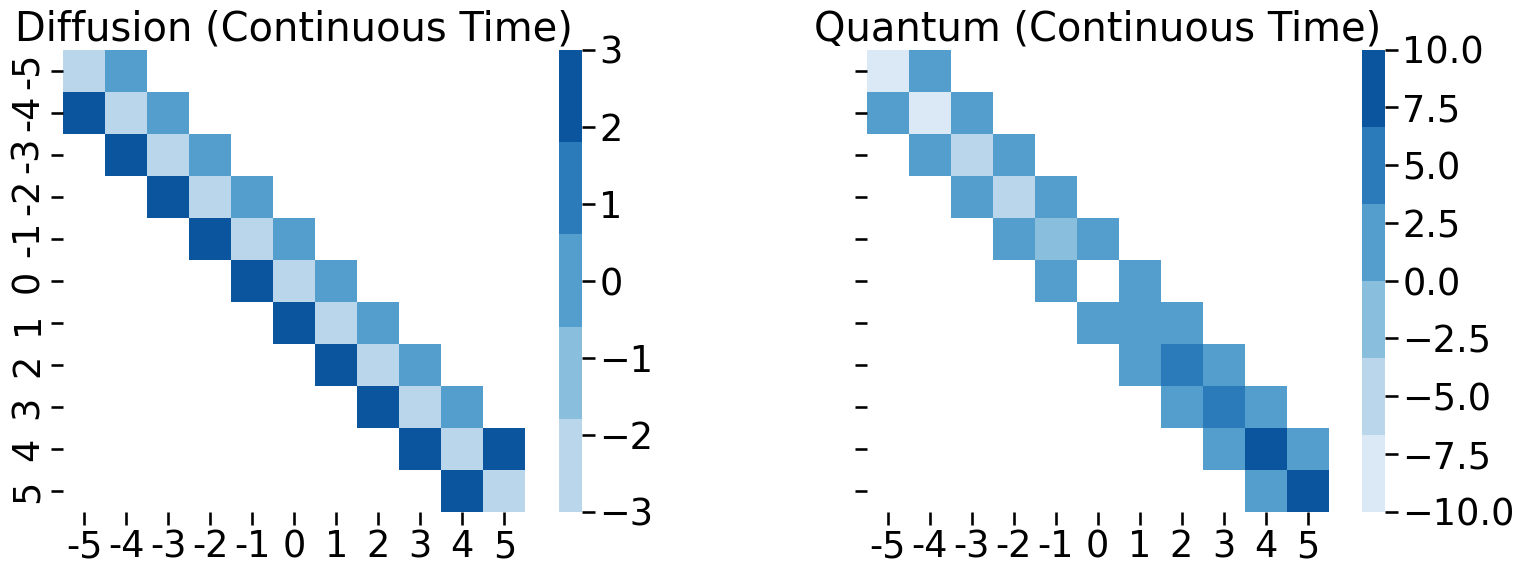

In [10]:
with sns.plotting_context("talk", font_scale=1.6):
    fig, axs = plt.subplots(1,2, figsize=(19,6), sharex=True, sharey=True)
   
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=mv_arr, yticklabels=mv_arr, square=True)
    axs[0].set_title("Diffusion (Continuous Time)")
    #axs[0].set_xlabel("Confidence States")
    #axs[1].set_xlabel("Confidence States")
    #axs[0].set_ylabel("Confidence States")
    intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
    sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = sns.color_palette("Blues"), 
                ax=axs[1], xticklabels=mv_arr, yticklabels=mv_arr, square=True)
    axs[1].set_title("Quantum (Continuous Time)")

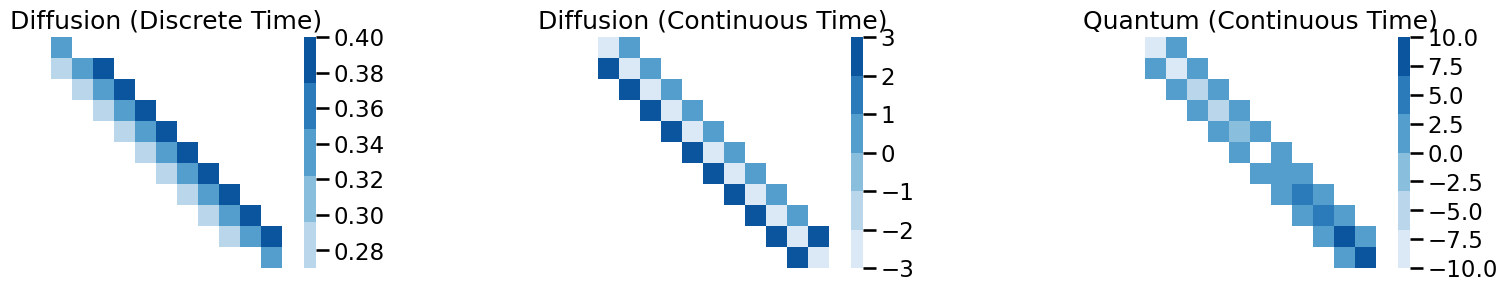

In [11]:
with sns.plotting_context("talk", font_scale=1):
    fig, axs = plt.subplots(1,3, figsize=(20,3), sharex=True, sharey=True)
    sns.heatmap(np.where(discrete_transition_matrix==0,np.nan,discrete_transition_matrix),  
    cmap = sns.color_palette("Blues")[1:], ax=axs[0], xticklabels=[], yticklabels=[], square=True)
    axs[0].set_title("Diffusion (Discrete Time)")
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = sns.color_palette("Blues"), ax=axs[1], xticklabels=[], yticklabels=[], square=True)
    axs[1].set_title("Diffusion (Continuous Time)")
    #axs[0].set_xlabel("Confidence States")
    #axs[1].set_xlabel("Confidence States")
    #axs[0].set_ylabel("Confidence States")
    intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
    sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = sns.color_palette("Blues"), 
                ax=axs[2], xticklabels=[], yticklabels=[], square=True)
    axs[2].set_title("Quantum (Continuous Time)")
    


In [12]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Uniform")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Uniform")
phi_0_markov, phi_0_quantum

(Array([[[[0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909]]]], dtype=float64),
 Array([[[[0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134]]]], dtype=float64))

In [33]:
phi_0_quantum1[:,:,[46, 47, 48, 49, 50, 51, 52, 53, 54],:]**2

Array([[[[0.11111111],
         [0.11111111],
         [0.11111111],
         [0.11111111],
         [0.11111111],
         [0.11111111],
         [0.11111111],
         [0.11111111],
         [0.11111111]]]], dtype=float64)

In [51]:
q_Mc1[[ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100],[ 91,  92,  93,  94,  95,  96,  97,  98,  99, 100]]**2

Array([0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25],      dtype=float64)

In [203]:
likl_markov_arr = []
likl_quantum_arr = []

m_mu1, m_sigma1, delta, T = npx.asarray([[0.56]]), npx.asarray([[20.09]]), 0.1, 60
q_mu1, q_sigma1, delta, T = npx.asarray([[2]]), npx.asarray([[1]]), 0.1, 60

for n, w, r in zip([11,51,101], [3,7,9], [1,5,10]):

    phi_0_markov1 = ca._get_initial_state(n, w,model_type="Markov", prior_type="Centered")
    phi_0_quantum1 = ca._get_initial_state(n, w,model_type="Quantum" , prior_type="Centered")

    intensity_matrix_markov1 = dd._buildK(n, m_mu1, m_sigma1)
    intensity_matrix_quantum1 = qd._buildH(n, q_mu1, q_sigma1)

    m_Mc1, m_Mw1, m_Mn1 = ca._get_measurement_matrix(n, r, prob=0.25, model_type = "Markov")
    q_Mc1, q_Mw1, q_Mn1 = ca._get_measurement_matrix(n, r, prob=0.25, model_type = "Quantum")

    import scipy as sci

    for t in np.arange(0,T,delta):
        likl_markov = ca.likelihood(intensity_matrix=intensity_matrix_markov1, phi_0=phi_0_markov1, delta=delta,
                                RT_s=npx.asarray([[t]]), RA_s=npx.asarray([[1]]),  
                                Mc=m_Mc1, Mw=m_Mw1, Mn=m_Mn1, 
                                transition_type="TIMESTEP", likelihood_type="SINGLE", model_type="Markov")
        likl_markov_arr.append(pd.DataFrame({"likl":(np.array(likl_markov).sum()), "model":"Markov", "time":[t], "states":n}))

        
        likl_quantum = ca.likelihood(intensity_matrix=intensity_matrix_quantum1, phi_0=phi_0_quantum1, delta=delta,
                                RT_s=npx.asarray([[t]]), RA_s=npx.asarray([[1]]),
                                Mc=q_Mc1, Mw=q_Mw1, Mn=q_Mn1, 
                                transition_type="TIMESTEP", likelihood_type="SINGLE", model_type="Quantum")

        likl_quantum_arr.append(pd.DataFrame({"likl":(np.array(likl_quantum).sum()), "model":"Quantum", "time":[t], "states":n}))

    #pd.DataFrame({"likl":likl_markov.squeeze(), "model":"Markov"})
    #pd.Series(npx.asarray(likl_quantum_arr), name="Quantum").plot()
    #plt.legend()
    #plt.show()
df_markov_plot_n = pd.concat(likl_markov_arr).astype({"states":"category"})
df_quantum_plot_n = pd.concat(likl_quantum_arr).astype({"states":"category"})
df_markov_plot_n

,likl,model,time,states
0,0.000000,Markov,0.0,7
0,0.011543,Markov,0.1,7
0,0.017656,Markov,0.2,7
0,0.019475,Markov,0.3,7
0,0.019475,Markov,0.4,7
...,...,...,...,...
0,0.000789,Markov,59.5,101
0,0.000787,Markov,59.6,101
0,0.000786,Markov,59.7,101
0,0.000784,Markov,59.8,101


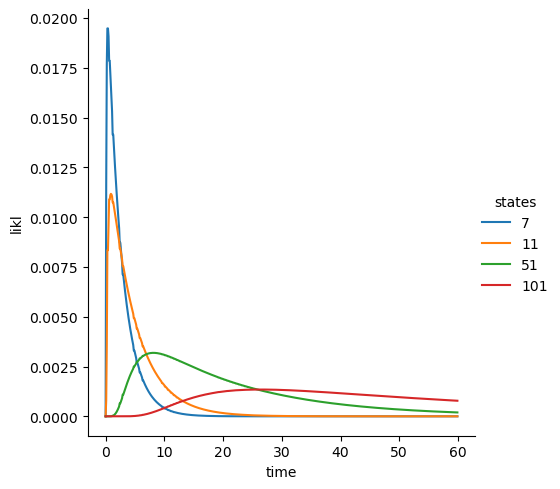

In [208]:
sns.relplot(df_markov_plot_n,
x="time", y="likl", hue="states", kind="line", facet_kws={"sharey":False})

In [258]:
def _buildH(m,a,b,c): 
# H = buildH(a,b,c)
# m = number of states  
# a = off diag left  
# b = diag  
# c = off diag right


    H = np.zeros((m, m))
    H[0,0] = b[0]
    H[0,1] = c[0]
    H[m-1, m-2] = a[m-1]
    H[m-1, m-1] = b[m-1]

    for k in range(1,m-1):
        H[k,k-1] = a[k]
        H[k,k] = b[k]
        H[k,k+1] = c[k]

    return H

mu=2
ap=1
delta2=0.1
T2 = 30
import itertools as iter
# Quantum working values ns, ws, rw  = [101], [40], [10], prob=0.25 tv = np.arange(0,30,0.1)
df_quantum_plot_n = []
#for ns, ws, rw, prob in zip([11, 51, 101], [4, 20, 40], [1, 5, 10], [0.8,0.5,0.25]): produces exact same results
for (ns, ws, rw), prob in iter.product (zip([11, 51, 101], [4, 20, 40], [1, 5, 10]), [0.1,0.2,0.3]):
#for ns, ws, rw in zip([101], [40], [10]):
    Mid = (ns+1)//2
    mv = np.arange(-(Mid-1), (Mid))
     
    b=mu*mv
    a=ap*np.ones((ns,1))

    H = _buildH(ns, a,b,a)
    tv = np.arange(0,T2,delta2)
    nt = tv.shape[0]
    
    Mc_arr = []
    Mc_arr_ts = []
    Pt_arr = []
    
    prob=prob
    Mr = np.zeros(ns)
    Mr[-rw:] = np.sqrt(prob)
    Mr = np.diag(Mr)

    Mi = np.zeros(ns)
    Mi[:rw] = np.sqrt(prob)
    Mi = np.diag(Mi)

    Mn = np.sqrt(np.eye(ns) - (Mr**2 + Mi**2))

    #print((Mr.T @ Mr + Mi.T @ Mi + Mn.T @ Mn)) # should be equal to 1

    S0 = np.zeros((ns,1))
    S0[Mid-ws-1:Mid+ws] = 1
    S0 = S0/np.sqrt(S0.T @ S0)


    for n in range(1,nt):
        #t = tv[n]
        U = sci.linalg.expm(-1j*delta2*H)
        St = Mr @ U @ np.linalg.matrix_power(Mn @ U, n-1) @ S0
        Pt = np.abs(St)**2
        Pt_arr.append(Pt.sum())
        Mc = mv @ Pt
        Mc_arr.append(Mc)


    ps = np.asarray(Pt_arr)
    #ps = ps/ps.sum()
    df_quantum_plot_n.append(pd.DataFrame({"likl":ps,"states":ns,"time":tv[1:], "prob":prob}))

    
df_quantum_plot_n = pd.concat(df_quantum_plot_n).astype({"prob":"category"})
df_quantum_plot_n

,likl,states,time,prob
0,0.000111,11,0.1,0.1
1,0.000421,11,0.2,0.1
2,0.000897,11,0.3,0.1
3,0.001511,11,0.4,0.1
4,0.002242,11,0.5,0.1
...,...,...,...,...
294,0.000023,101,29.5,0.3
295,0.000024,101,29.6,0.3
296,0.000025,101,29.7,0.3
297,0.000025,101,29.8,0.3


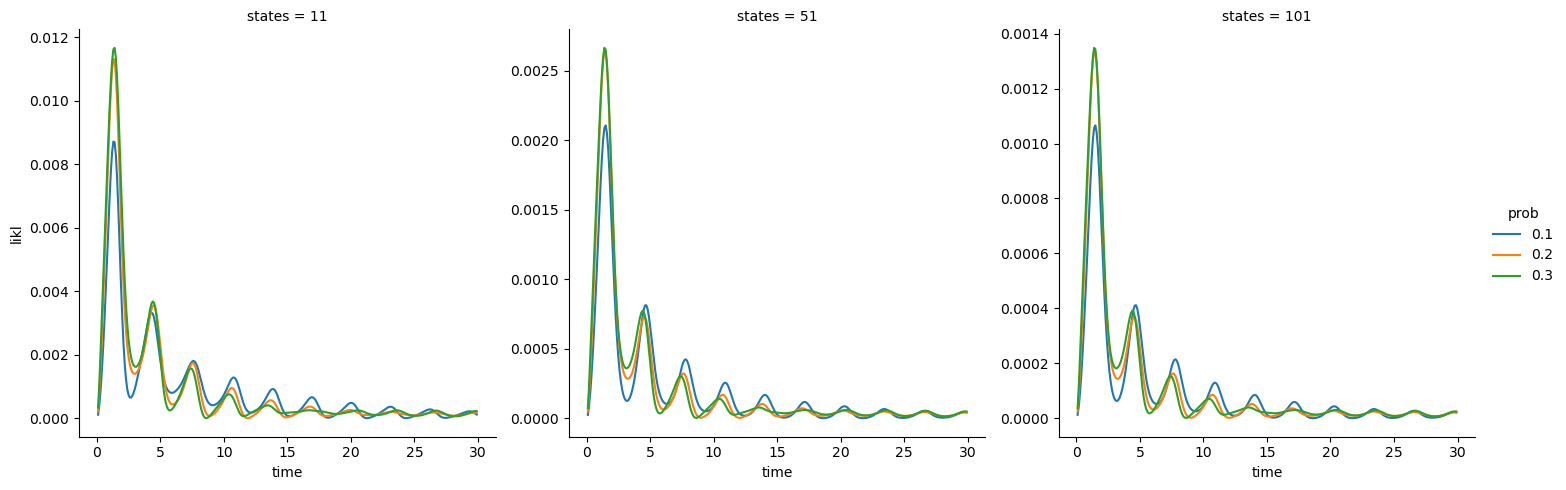

In [259]:
sns.relplot(df_quantum_plot_n,
x="time", y="likl", col="states", hue="prob", kind="line", facet_kws={"sharey":False})

In [138]:
Pt.sum()

2.4064984406430507e-71

In [103]:
Mr

array([[0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0.5]])

In [58]:
pd.Series(npx.asarray(likl_quantum_arr), name="Quantum").plot()

TypeError: no numeric data to plot

In [13]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,10,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,10,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [14]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-5,Upper,0.0,0.028271723245087158,0.03402818145137997
1,-4,Upper,0.0,0.029475005371642014,0.07852552357744298
2,-3,Upper,0.0,-0.015285833449119116,0.10086759066097882
3,-2,Upper,0.0,-0.03269795327018755,0.052316254681053664
4,-1,Upper,0.0,0.061854809730757104,-0.004053993853862153
...,...,...,...,...,...
32665,1,Lower,98.9,-0.030683496778032865,-0.06456639756270853
32666,2,Lower,98.9,0.00895352475445812,0.10861681883211617
32667,3,Lower,98.9,0.03864694525696644,0.030173504673024445
32668,4,Lower,98.9,-0.04016134780029479,-0.08987944236203398


In [94]:
df_quantum_3d_plot1 = df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 1").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}) #\
                 #.query("state_labels == -100")

df_quantum_3d_plot1

,states,prior,Time,Real,Imaginary,state_labels
11,-5,Uniform,0.0,0.024834912154251217,0.01785963860259809,-100
12,-4,Uniform,0.0,-0.05667382617773866,-0.024110321262837065,-90
13,-3,Uniform,0.0,0.03396645928700979,0.0069406676842991765,-80
14,-2,Uniform,0.0,-0.0676371022467614,0.078454795920665,-70
15,-1,Uniform,0.0,0.22276756843653267,-0.056810873270700724,-60
...,...,...,...,...,...,...
3284,1,Uniform,0.99,0.10084745932101889,-0.20351920484072536,60
3285,2,Uniform,0.99,0.5831789648472422,-0.043708263878796366,70
3286,3,Uniform,0.99,-0.19355360321645826,0.014241772636705133,80
3287,4,Uniform,0.99,0.2569889425806169,-0.2846179488087488,90


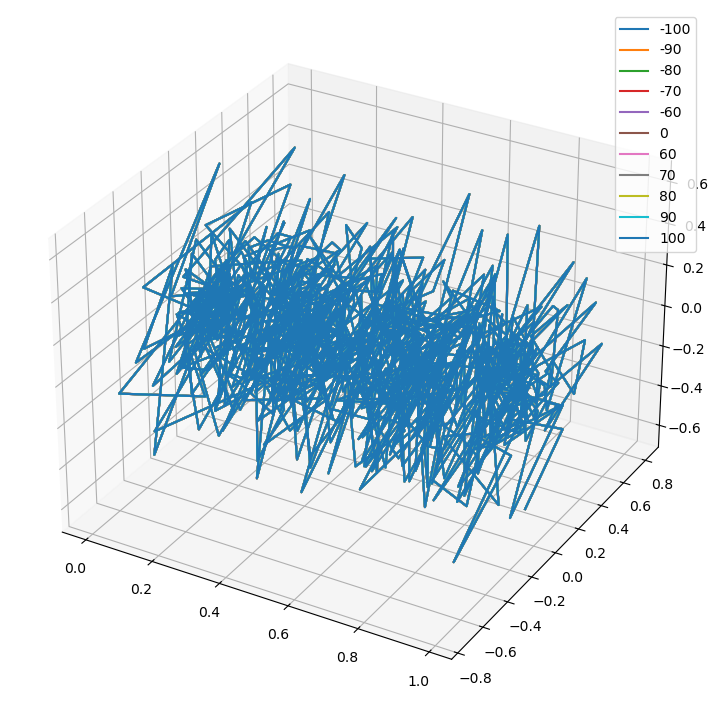

In [98]:
import mpl_toolkits
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), figsize = (19,9))
for k, df in df_quantum_3d_plot1.groupby("state_labels"):
    ax.plot(df_quantum_3d_plot1.Time, df_quantum_3d_plot1.Real, df_quantum_3d_plot1.Imaginary, label=k)
#mpl_toolkits.mplot3d.art3d.Line3D(df_quantum_3d_plot1.Time, df_quantum_3d_plot1.Real, df_quantum_3d_plot1.Imaginary)
plt.legend()

In [15]:
import plotly.express as px
pio.renderers.default = "browser" #"vscode" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 1").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Random Walk - Probability "Amplitude" (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
#import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

In [16]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

In [17]:
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma_coef[0], mu,samples = 50, process="Wiener",njobs=1, scale_steps_to_boundary=False)
np.asarray(RT_arr)

array([0.18, 0.13, 0.1 , 0.06, 0.26, 0.22, 0.02, 0.09, 0.42, 0.33, 0.34,
       0.44, 0.09, 0.07, 0.32, 0.04, 0.1 , 0.8 , 0.08, 0.4 , 0.16, 0.23,
       0.2 , 0.13, 0.39, 0.04, 0.08, 0.19, 0.41, 0.15, 0.34, 0.01, 0.37,
       0.13, 0.09, 0.11, 0.22, 0.97, 0.63, 0.27, 0.19, 0.08, 0.07, 0.01,
       0.03, 0.1 , 0.31, 0.57, 0.15, 0.14])

In [18]:
df_t = pd.DataFrame({"steps":np.asarray(steps_arr[0])}).reset_index(names="time").assign(time = lambda df: df.time * tau)
df_t

,time,steps
0,0.00,-2
1,0.01,-2
2,0.02,-1
3,0.03,-2
4,0.04,-2
5,0.05,-1
6,0.06,-1
7,0.07,-2
8,0.08,-2
9,0.09,-2


In [19]:
df_markov_plot.query("time <= 20 and prior=='Uniform'")

,states,prior,time,value
11,-5,Uniform,0.0,0.090909
12,-4,Uniform,0.0,0.090909
13,-3,Uniform,0.0,0.090909
14,-2,Uniform,0.0,0.090909
15,-1,Uniform,0.0,0.090909
...,...,...,...,...
6617,1,Uniform,20.0,0.003840
6618,2,Uniform,20.0,0.019200
6619,3,Uniform,20.0,0.096000
6620,4,Uniform,20.0,0.480000


In [20]:
df_markov_plot.query("time >= 96")

,states,prior,time,value
31680,-5,+High,96.0,2.048000e-07
31681,-4,+High,96.0,1.228800e-06
31682,-3,+High,96.0,6.144001e-06
31683,-2,+High,96.0,3.072000e-05
31684,-1,+High,96.0,1.536000e-04
...,...,...,...,...
32698,1,-High,99.0,3.840000e-03
32699,2,-High,99.0,1.920000e-02
32700,3,-High,99.0,9.600001e-02
32701,4,-High,99.0,4.800000e-01


<Axes: xlabel='time', ylabel='states'>

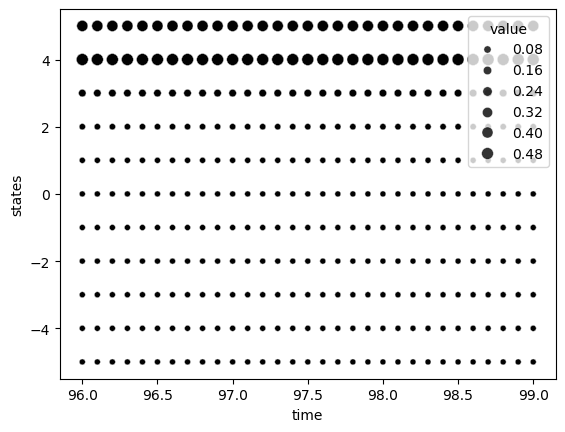

In [21]:
sns.scatterplot(df_markov_plot
                    .query("time >= 96"),
                    alpha=0.8, 
    x="time", y="states",size="value", color="Black")

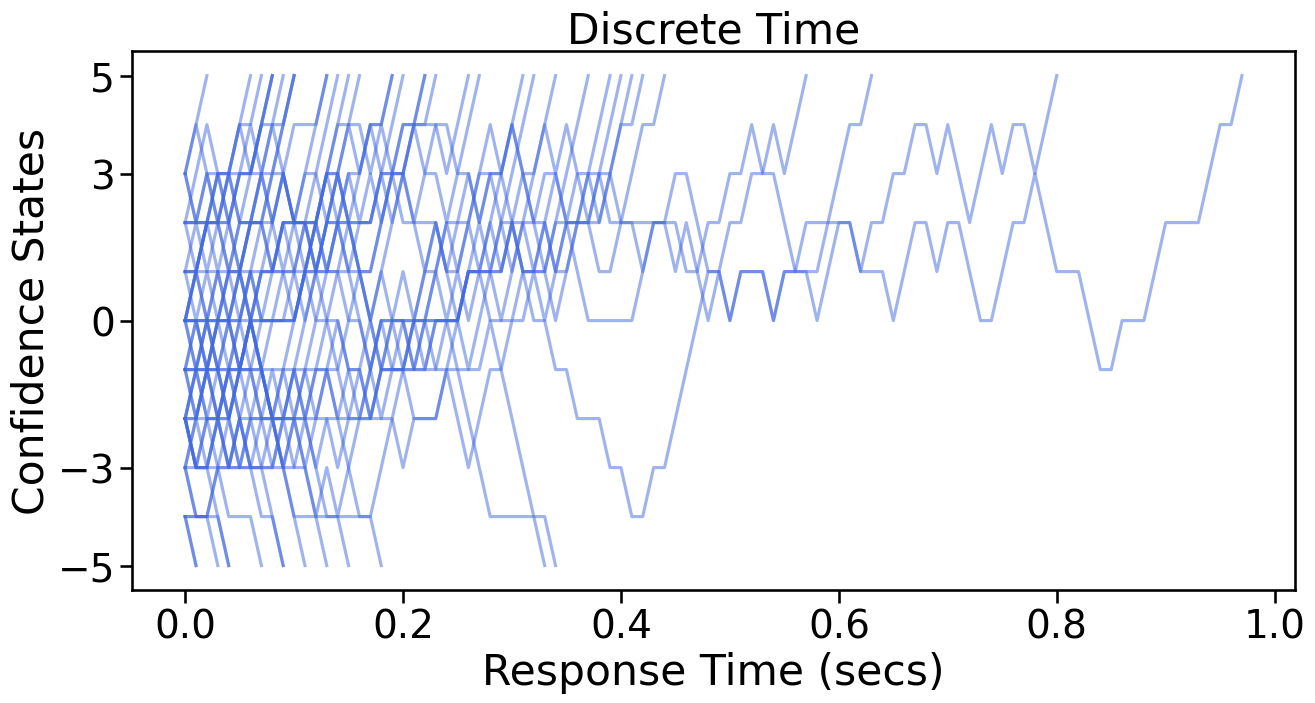

In [22]:
with sns.plotting_context("talk", font_scale=1.7):
    for st in steps_arr:
        df_t = pd.DataFrame({"steps":np.asarray(st)}).reset_index(names="time").assign(time = lambda df: df.time * tau)
        f = sns.lineplot(df_t,
        x="time", color="royalblue", alpha=0.5,
        y="steps")
        f.set_ylabel("Confidence States")
        f.set_xlabel("Response Time (secs)")
        f.set_title("Discrete Time")
f.figure.set_size_inches(15,7)
f.set_yticks([-5,-3,0,3,5])

/tmp/ipykernel_48446/242141150.py:22: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



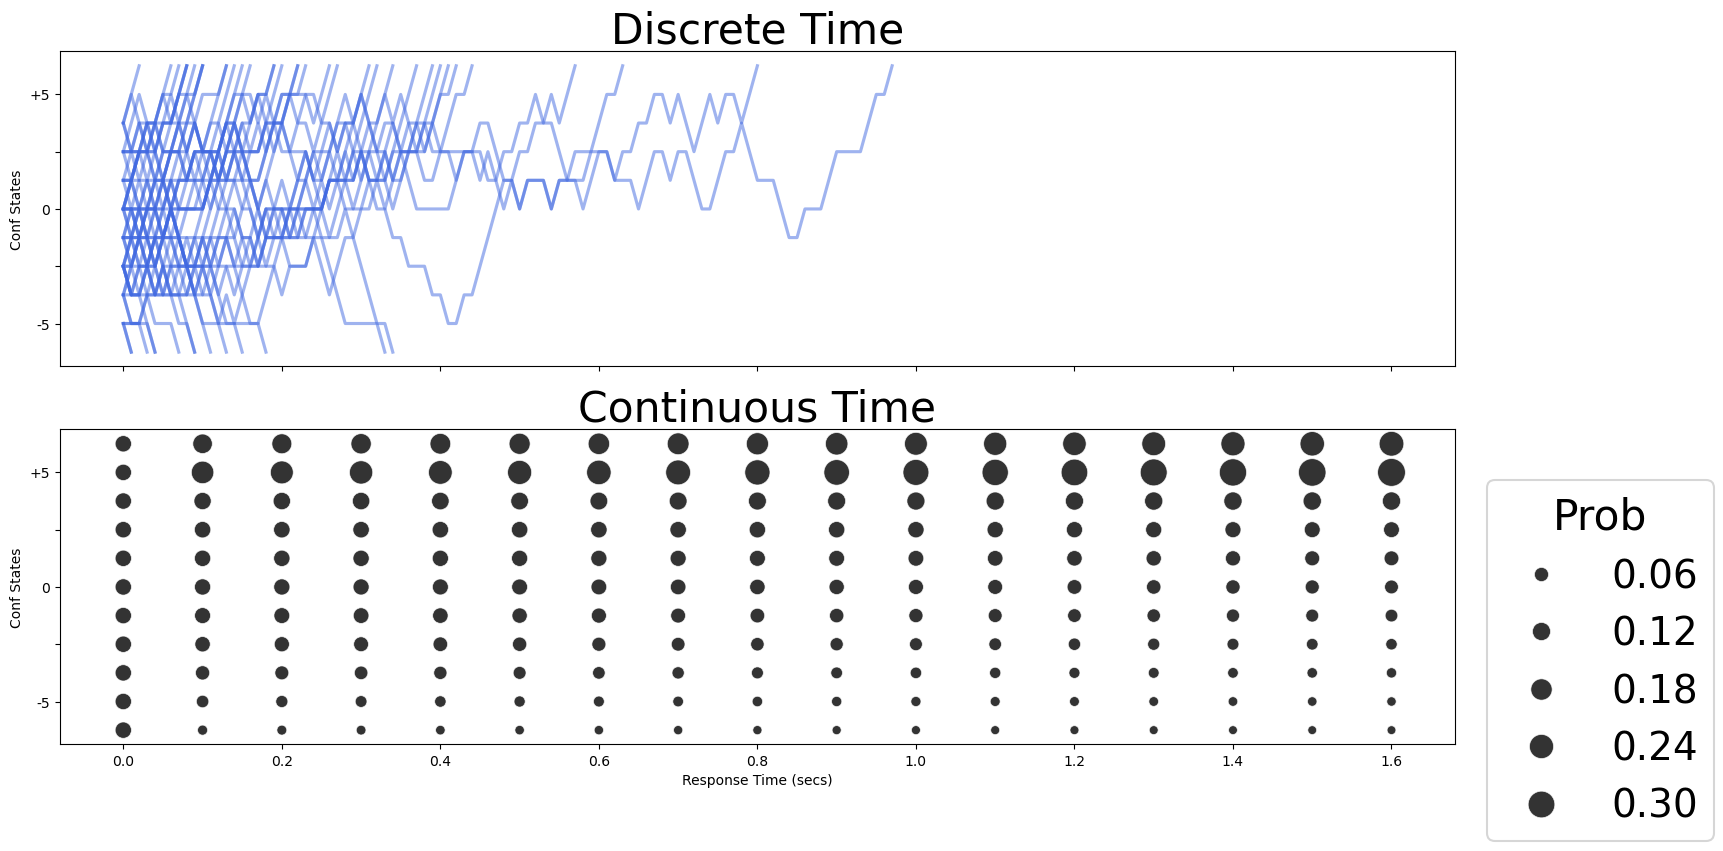

In [23]:
fig, axs = plt.subplots(2,1, figsize=(18,9), sharey=True, sharex=True)

with sns.plotting_context("talk", font_scale=1.7):
    for st in steps_arr:
        df_t = pd.DataFrame({"steps":np.asarray(st)}).reset_index(names="time").assign(time = lambda df: df.time * tau)
        f = sns.lineplot(df_t,
        x="time", color="royalblue", alpha=0.5,
        y="steps", ax=axs[0])
        f.set_ylabel("Conf States")
        f.set_xlabel("Response Time (secs)")
        f.set_title("Discrete Time")
    f = sns.scatterplot(df_markov_plot.assign(model="Diffusion")
                        .query("time <= 1.6 and prior == 'Uniform'")
                        ,alpha=0.8, ax=axs[1], legend=True,
        x="time", y="states",size="value", sizes=(40,400), color="Black")

    #f.legend.set_title("Prob")
    f.set_xlabel("Response Time (secs)")
    f.set_ylabel("Conf States")
    f.set_title("Continuous Time")
    #f.set_ylabels("Conf States")
    f.set_yticklabels(["","-5","","0","","+5"])    
    f.legend(title="Prob", bbox_to_anchor=(1.009,0.9))


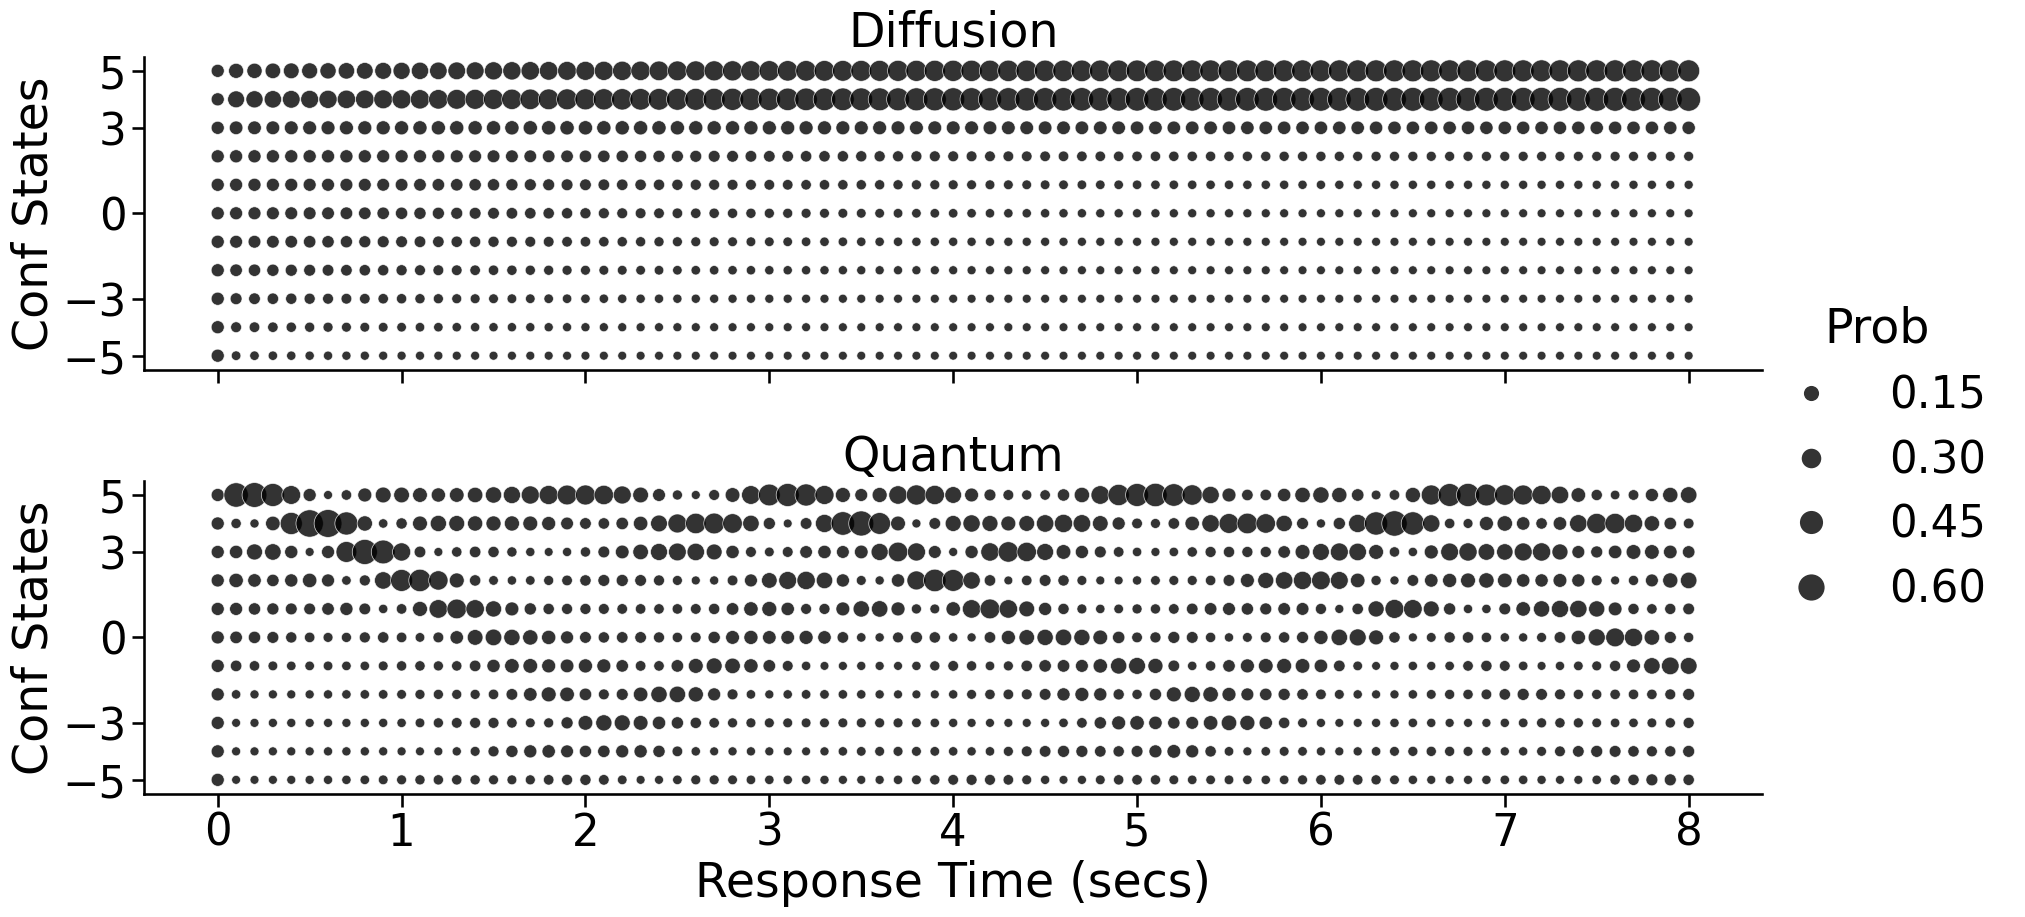

In [24]:
with sns.plotting_context("talk",font_scale=1.9):
    f = sns.relplot(pd.concat([df_markov_plot.assign(model="Diffusion"), df_quantum_plot.assign(model="Quantum")])
                    .query("time <= 8 and prior == 'Uniform'")
                    ,alpha=0.8, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=3.7, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    #f.set(ylim=(-5.5, 5.5))
    #f.set_yticklabels(["-5","","0","","+5"]) 
    f.set(yticks=[-5,-3,0,3,5])

In [52]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
m_mu_arr, m_sigma, T = [npx.asarray([[0.1]]), npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[3]])], npx.asarray([[3]]), 100
q_mu_arr, q_sigma, T = [npx.asarray([[0.1]]), npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[3]])], npx.asarray([[3]]), 100


for m_mu, q_mu in zip(m_mu_arr, q_mu_arr):
    intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

        phi_markov_arr = []
        phi_quantum_arr = []
        phi_quantum_arr_r = []
        phi_quantum_arr_c = []

        phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
        phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

        #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
        #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
        #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
        #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        
        for t in np.arange(1,10,delta):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
        for t in np.arange(1,10,delta):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
                  
        df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=m_mu[0,0].item())])
        df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=q_mu[0,0].item())])
        
        

In [53]:
df_markov.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time")#.assign(time = lambda df:df.time*delta)

,prior,mu,time,value
0,Upper,0.1,0,0.000000e+00
1,Upper,0.1,0,0.000000e+00
2,Upper,0.1,0,0.000000e+00
3,Upper,0.1,0,0.000000e+00
4,Upper,0.1,0,0.000000e+00
...,...,...,...,...
6,Lower,3.0,90,2.988736e-08
7,Lower,3.0,90,1.320521e-07
8,Lower,3.0,90,5.112699e-07
9,Lower,3.0,90,4.999999e-01


In [54]:
df_markov_plot1 = df_markov.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot1 = df_quantum.melt(id_vars = ["prior", "mu"], ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot1 = df_markov_plot1.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot1 = df_quantum_plot1.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

In [55]:
df_conf_plot = pd.concat([df_markov_plot1.assign(model="Diffusion"), df_quantum_plot1.assign(model="Quantum")])
df_conf_plot= df_conf_plot.groupby(["prior", "mu", "time", "model"])["value"].apply(lambda ds: (mv_arr*ds).sum()).reset_index(name="conf_state")
df_conf_plot

,prior,mu,time,model,conf_state
0,+High,0.1,0.0,Diffusion,3.000000
1,+High,0.1,0.0,Quantum,3.000000
2,+High,0.1,0.1,Diffusion,2.642129
3,+High,0.1,0.1,Quantum,2.261531
4,+High,0.1,0.2,Diffusion,2.612051
...,...,...,...,...,...
2179,Uniform,3.0,8.8,Quantum,1.884203
2180,Uniform,3.0,8.9,Diffusion,4.499999
2181,Uniform,3.0,8.9,Quantum,1.722447
2182,Uniform,3.0,9.0,Diffusion,4.499999


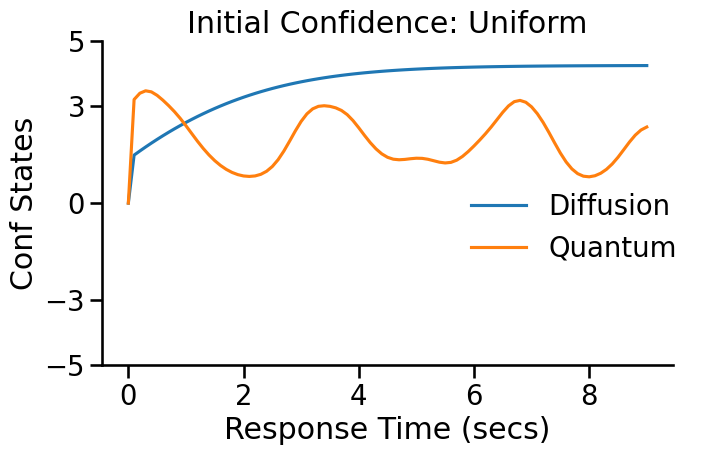

In [61]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_conf_plot.query("mu==2 and time < 25"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["Uniform"]
                )
    f.legend.set_title("")
    f.set_titles("Initial Confidence: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    plt.tight_layout()

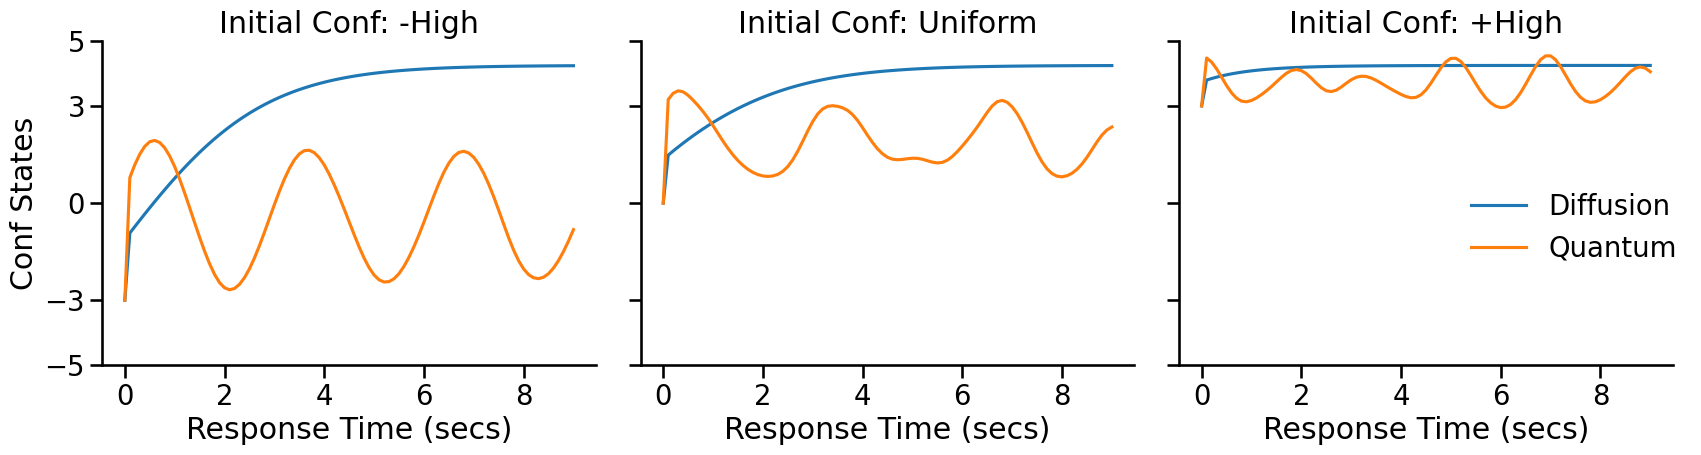

In [60]:
with sns.plotting_context("talk", font_scale=1.2):
    f = sns.relplot(df_conf_plot.query("mu==2 and time < 25"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["-High", "Uniform", "+High"]
                )
    f.legend.set_title("")
    f.set_titles("Initial Conf: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    plt.tight_layout()

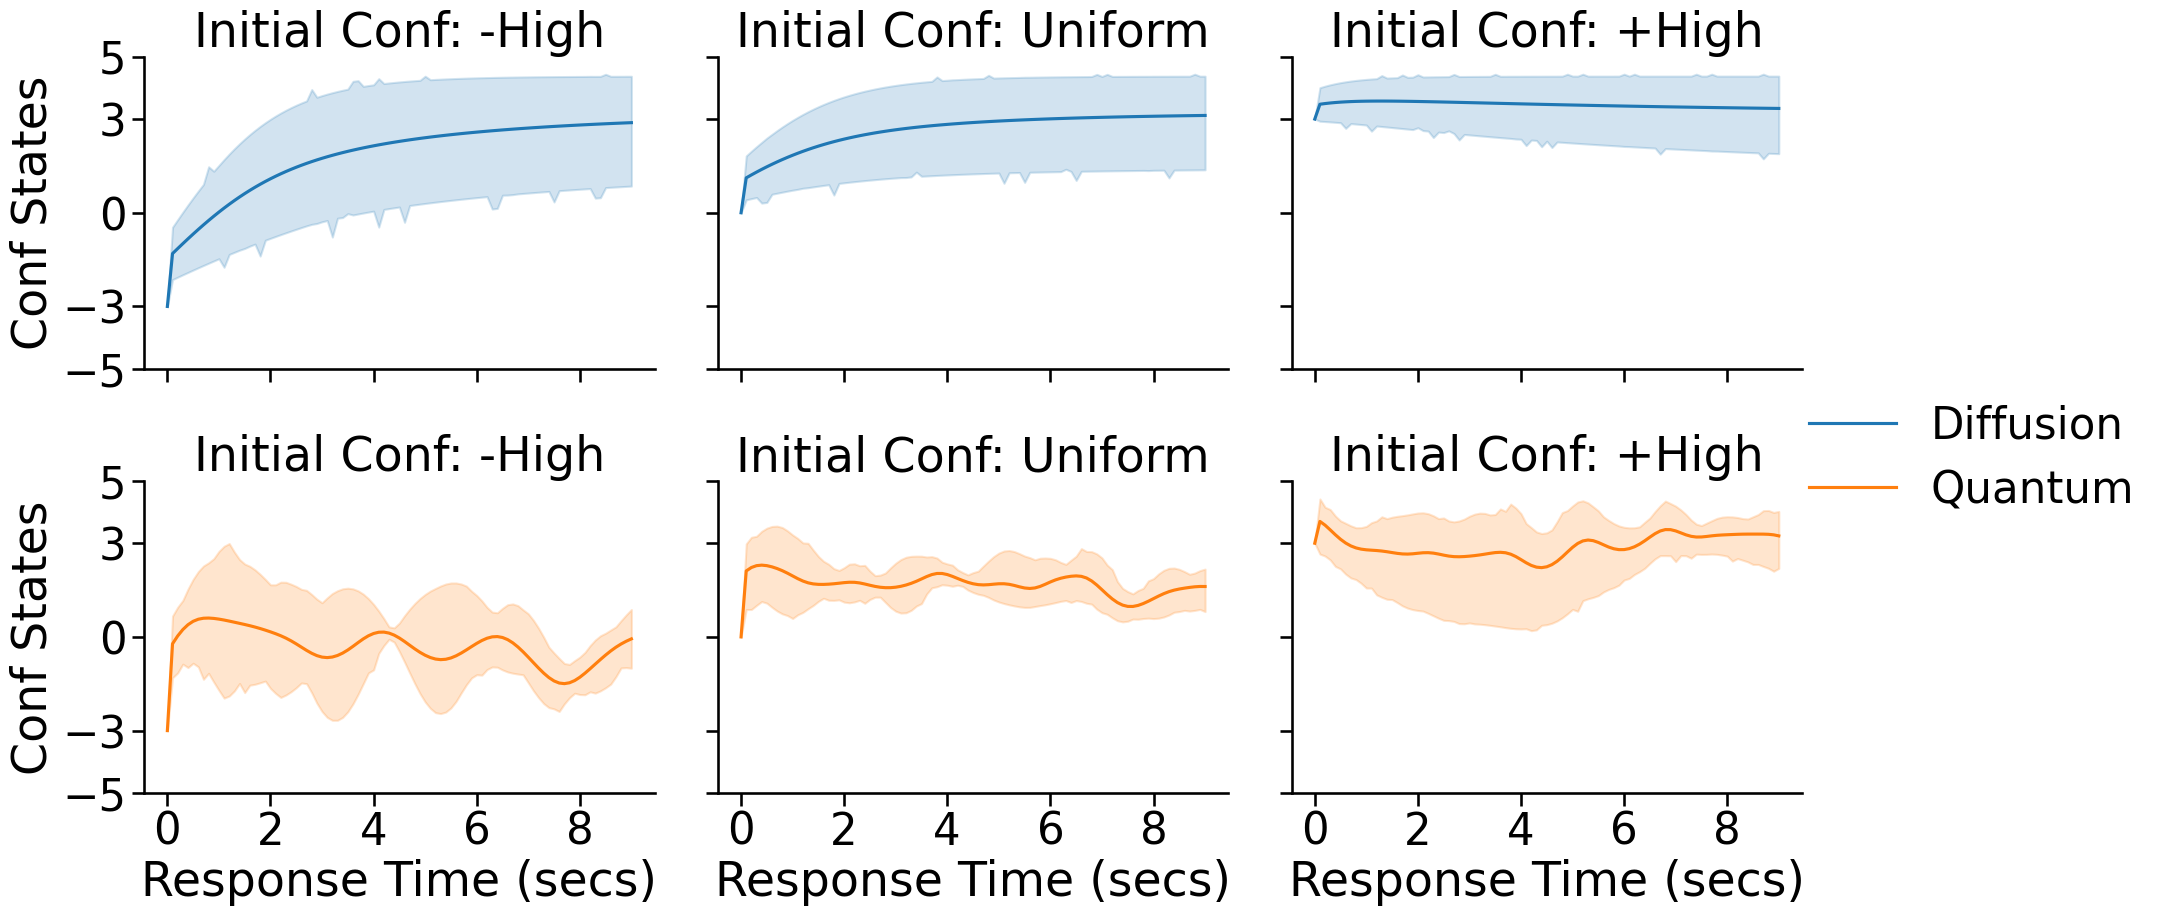

In [57]:
with sns.plotting_context("talk", font_scale=1.9):
    f = sns.relplot(df_conf_plot.query("time < 25"), x="time", y="conf_state", col="prior",hue="model", kind="line",
                col_order=["-High", "Uniform", "+High"], row="model", aspect=1.3
                )
    f.legend.set_title("")
    f.set_titles("Initial Conf: {col_name}")
    f.set_xlabels("Response Time (secs)")
    f.set_ylabels("Conf States")
    f.set(yticks=[-5,-3,0,3,5])
    #plt.tight_layout()